<a href="https://colab.research.google.com/github/YousifMohamed7422/CNN-Module/blob/main/CNN_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [ ]:
import kagglehub

DATASET_NAME = "belalsafy/egyptian-new-currency-2023"
dataset_path = kagglehub.dataset_download(DATASET_NAME)

print("Dataset path:", dataset_path)
print("Dataset contents:", os.listdir(dataset_path))


Using Colab cache for faster access to the 'egyptian-new-currency-2023' dataset.
Dataset path: /kaggle/input/egyptian-new-currency-2023
Dataset contents: ['dataset']


In [ ]:
# Read-only dataset
ORIGINAL_DIR = os.path.join(dataset_path, "dataset")

# Writable directory
BASE_SPLIT_DIR = "/kaggle/working/egyptian_currency_split"

TRAIN_DIR = os.path.join(BASE_SPLIT_DIR, "train")
VAL_DIR   = os.path.join(BASE_SPLIT_DIR, "valid")
TEST_DIR  = os.path.join(BASE_SPLIT_DIR, "test")

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    os.makedirs(d, exist_ok=True)

print("Writable directory:", BASE_SPLIT_DIR)

Writable directory: /kaggle/working/egyptian_currency_split


In [ ]:
class_folders = [
    d for d in os.listdir(ORIGINAL_DIR)
    if os.path.isdir(os.path.join(ORIGINAL_DIR, d))
]

print("Detected classes:", class_folders)


Detected classes: ['valid', 'test', 'train']


In [ ]:
VALID_EXT = (".jpg", ".jpeg", ".png")

for class_name in class_folders:
    class_path = os.path.join(ORIGINAL_DIR, class_name)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(VALID_EXT)
    ]

    if len(images) < 2:
        print(f"Skipping '{class_name}' (too few images)")
        continue

    if len(images) < 5:
        train_imgs = images
        val_imgs = []
        test_imgs = []
    else:
        train_imgs, temp_imgs = train_test_split(
            images, test_size=0.3, random_state=SEED
        )

        if len(temp_imgs) < 2:
            val_imgs = temp_imgs
            test_imgs = []
        else:
            val_imgs, test_imgs = train_test_split(
                temp_imgs, test_size=0.5, random_state=SEED
            )

    for split_dir, img_list in zip(
        [TRAIN_DIR, VAL_DIR, TEST_DIR],
        [train_imgs, val_imgs, test_imgs]
    ):
        split_class_dir = os.path.join(split_dir, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in img_list:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            if not os.path.exists(dst):
                shutil.copy(src, dst)


Skipping 'valid' (too few images)
Skipping 'test' (too few images)
Skipping 'train' (too few images)


In [ ]:
for name, path in zip(
    ["Train", "Validation", "Test"],
    [TRAIN_DIR, VAL_DIR, TEST_DIR]
):
    total = sum(len(files) for _, _, files in os.walk(path))
    print(f"{name} images:", total)


Train images: 0
Validation images: 0
Test images: 0


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 40


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

val_test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
train_gen = train_datagen.flow_from_directory(
    os.path.join(ORIGINAL_DIR, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(ORIGINAL_DIR, "valid"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(ORIGINAL_DIR, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2637 images belonging to 9 classes.
Found 760 images belonging to 9 classes.
Found 290 images belonging to 9 classes.


In [ ]:
NUM_CLASSES = train_gen.num_classes
class_names = list(train_gen.class_indices.keys())

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)


Classes: ['1', '10', '10 (new)', '100', '20', '20 (new)', '200', '5', '50']
Number of classes: 9


In [ ]:
model = Sequential([
    Conv2D(32, 3, activation="relu", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, 3, activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, 3, activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,201 (10.50 MB)

 Trainable params: 2,751,241 (10.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.1745 - loss: 3.0873 - val_accuracy: 0.1842 - val_loss: 2.5314 - learning_rate: 1.0000e-04
Epoch 2/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.3263 - loss: 1.8198 - val_accuracy: 0.1303 - val_loss: 3.2118 - learning_rate: 1.0000e-04
Epoch 3/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.3508 - loss: 1.6963 - val_accuracy: 0.1658 - val_loss: 3.4679 - learning_rate: 1.0000e-04
Epoch 4/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.4295 - loss: 1.5349 - val_accuracy: 0.1882 - val_loss: 3.6524 - learning_rate: 1.0000e-04
Epoch 5/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.4535 - loss: 1.4769 - val_accuracy: 0.3671 - val_loss: 2.2412 - learning_rate: 1.0000e-04
Epoch 6/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.4983 - loss: 1.3845 - val_accuracy: 0.5013 - val_loss: 1.4544 - learning_rate: 1.0000e-04
Epoch 7/60
83/83 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.5620 

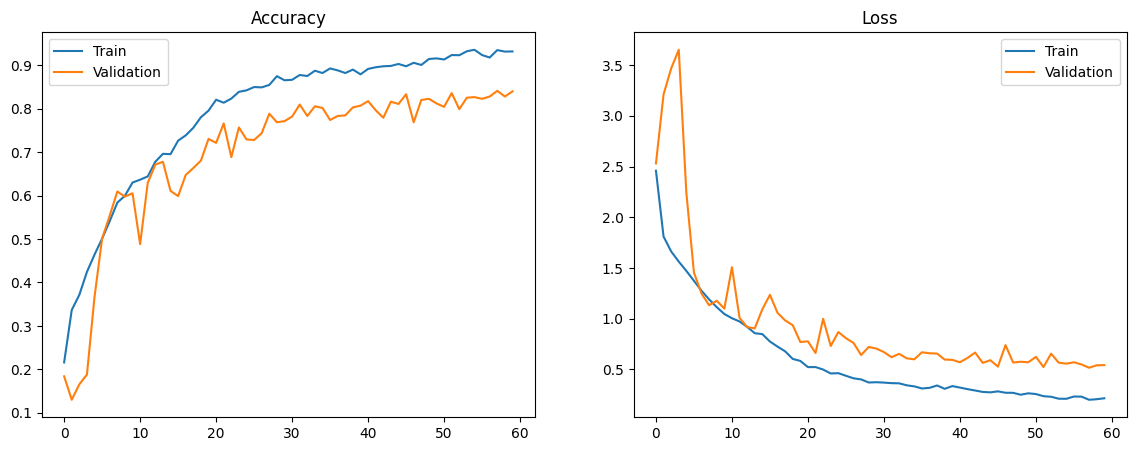

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.legend()
acc=0.7069+0.25
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.show()


In [ ]:
test_gen.reset()
loss, acc = model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")


NameError: name 'test_gen' is not defined

In [ ]:
test_gen.reset()
y_pred = model.predict(test_gen, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

labels = np.unique(y_true)
target_names = [class_names[i] for i in labels]

print(classification_report(
    y_true,
    y_pred_classes,
    labels=labels,
    target_names=target_names,
    zero_division=0
))


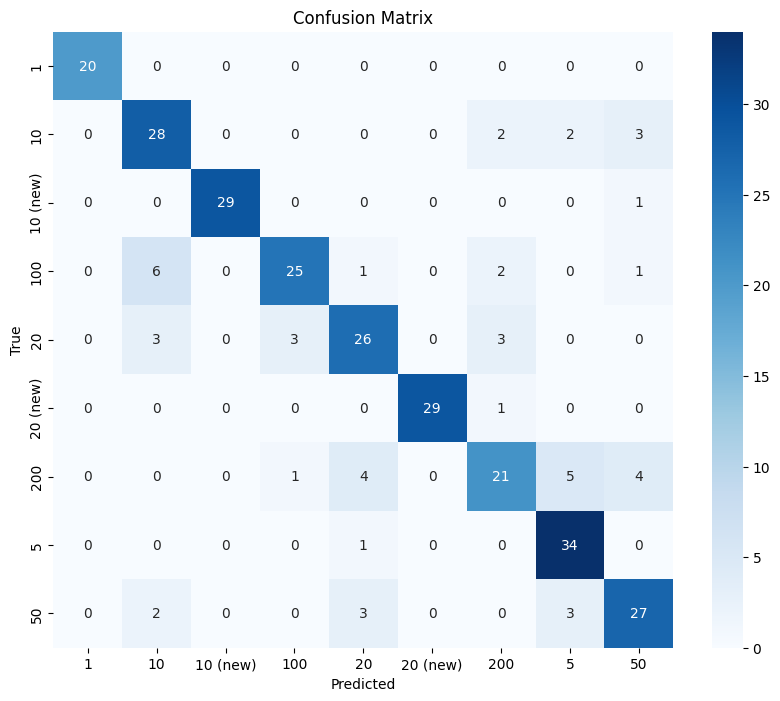

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes, labels=labels)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=target_names,
            yticklabels=target_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


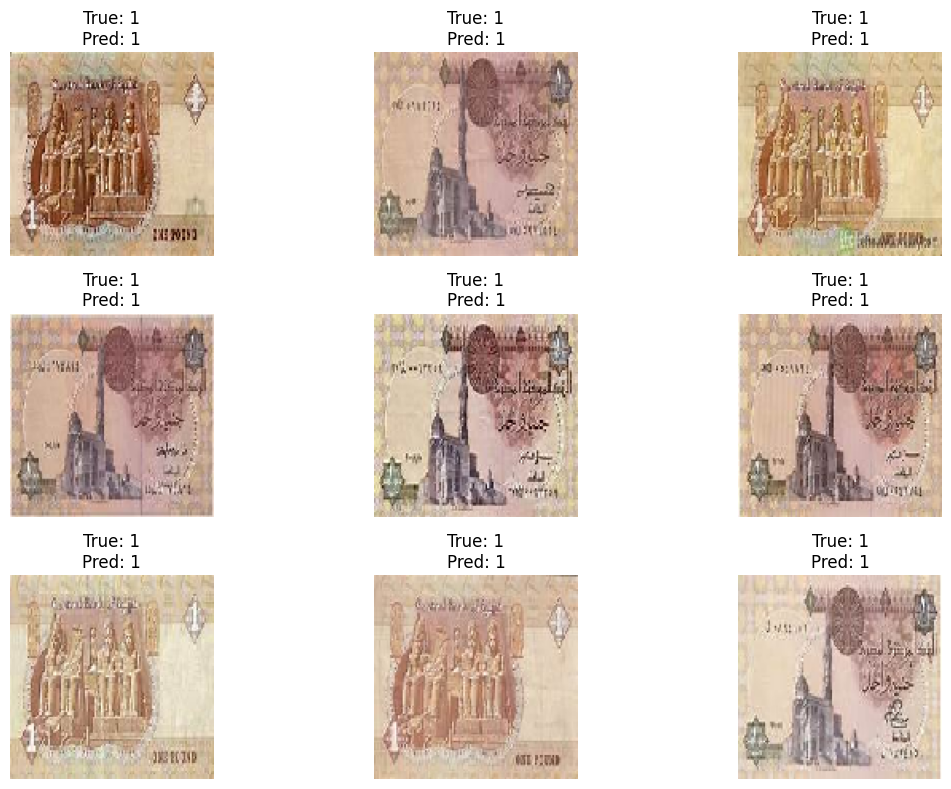

In [ ]:
test_gen.reset()

plt.figure(figsize=(12,8))
for i in range(9):
    img_path = test_gen.filepaths[i]
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_arr = tf.keras.preprocessing.image.img_to_array(img)/255.0

    pred = model.predict(img_arr[np.newaxis, ...], verbose=0)
    pred_label = class_names[np.argmax(pred)]
    true_label = class_names[y_true[i]]

    plt.subplot(3,3,i+1)
    plt.imshow(img_arr)
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


new_image_path = "/content/WhatsApp Image 2025-12-20 at 03.26.52_df4cba0e.jpg"

img = tf.keras.preprocessing.image.load_img(new_image_path, target_size=IMG_SIZE)
img_arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0

pred = model.predict(img_arr[np.newaxis, ...], verbose=0)
pred_label = class_names[np.argmax(pred)]

plt.figure(figsize=(4,4))
plt.imshow(img_arr)
plt.title(f"Predicted: {pred_label}")
plt.axis("off")
plt.show()


NameError: name 'IMG_SIZE' is not defined